In [ ]:
# Day 1: YOLOv8 Inference Basics

# Install and load the model
# Run inference on images
# Understand outputs (bounding boxes, confidence, class IDs)
# Visualize detections

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.8 MB/s eta 0:00:00


In [ ]:
from PIL import Image

img = Image.open('/content/Ney pic.jfif')
img.save('/content/ney.jpg', 'JPEG')
print(f"Converted! Size: {img.size}")

Converted! Size: (149, 148)


In [ ]:
results = model.predict(source='/content/ney.jpg', conf=0.55)

for r in results:
    print(f"Total detections: {len(r.boxes)}")
    for box in r.boxes:
        print(f"  Confidence: {box.conf[0]:.2f}")


image 1/1 /content/ney.jpg: 640x640 1 person, 227.4ms
Speed: 6.1ms preprocess, 227.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Total detections: 1
  Confidence: 0.58


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.predict(source='/content/ney.jpg', conf=0.3)

for r in results:
    print(f"Image size: {r.orig_shape}")
    print(f"Total detections: {len(r.boxes)}")
    for box in r.boxes:
        print(f"  Class ID: {int(box.cls[0])}, Confidence: {box.conf[0]:.2f}")


image 1/1 /content/ney.jpg: 640x640 3 persons, 243.0ms
Speed: 7.1ms preprocess, 243.0ms inference, 24.3ms postprocess per image at shape (1, 3, 640, 640)
Image size: (148, 149)
Total detections: 3
  Class ID: 0, Confidence: 0.58
  Class ID: 0, Confidence: 0.47
  Class ID: 0, Confidence: 0.35


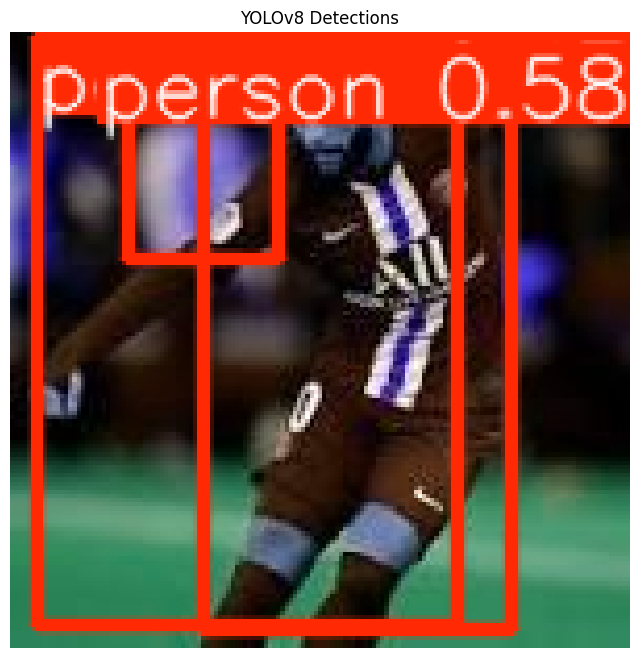

In [ ]:
import cv2
from PIL import Image as PILImage
import matplotlib.pyplot as plt

# Plot boxes on image
annotated = results[0].plot()

# Display it
plt.figure(figsize=(8, 8))
plt.imshow(annotated)
plt.axis('off')
plt.title('YOLOv8 Detections')
plt.show()